# Lecture 3: Building Tables, Census, and Charts

---

## Overview

* [Creating Tables](#Creating-Tables)
* [Columns and Rows of Tables](#Columns-and-Rows-of-Tables)
* [Attribute Types](#Attribute-Types)
* [Exploring the Tallest_Buildings](#Exploring-the-Tallest-Buildings)
* [Exploring Movies](#Exploring-Movies)

---

## Set Up the Notebook

In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

---

## Creating Tables

Here are *some* of the ways that you will create a table in this class:
* `Table.read_table(filename)` - a table from a CSV file
* `Table()` - an empty table
* `select`, `drop`, `where`, `sort`, etc. - a table from existing tables
* `with_column` and `with_columns` - a table from an existing table with additional columns
* `with_row` and `with_rows` - a table from an existing table with additional rows
* `take` and `exclude` - a table formed from a subset of rows from an existing table

---

### Demo: Using `read_table`

“The NBA is the highest paying professional sports league in the world,” reported CNN in March 2016. The table nba_salaries contains the salaries of all National Basketball Association players in 2015-2016.

Each row represents one player

In [2]:
# This table can be found online: https://www.statcrunch.com/app/index.php?dataid=1843341
nba_salaries = Table.read_table('nba_salaries.csv')
nba_salaries

rank,name,position,team,salary,season
1,Shaquille O'Neal,C,Los Angeles Lakers,17142000,2000
2,Kevin Garnett,PF,Minnesota Timberwolves,16806000,2000
3,Alonzo Mourning,C,Miami Heat,15004000,2000
4,Juwan Howard,PF,Washington Wizards,15000000,2000
5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000
6,Karl Malone,PF,Utah Jazz,14000000,2000
7,Larry Johnson,F,New York Knicks,11910000,2000
8,Gary Payton,PG,Seattle SuperSonics,11020000,2000
9,Rasheed Wallace,PF,Portland Trail Blazers,10800000,2000
10,Shawn Kemp,C,Cleveland Cavaliers,10780000,2000


---

### Demo: Tables from Tables

Most (not all) of the table methods create a new table and do not modify the original table.

In [3]:
nba_salaries.select('name', 'team')

name,team
Shaquille O'Neal,Los Angeles Lakers
Kevin Garnett,Minnesota Timberwolves
Alonzo Mourning,Miami Heat
Juwan Howard,Washington Wizards
Scottie Pippen,Portland Trail Blazers
Karl Malone,Utah Jazz
Larry Johnson,New York Knicks
Gary Payton,Seattle SuperSonics
Rasheed Wallace,Portland Trail Blazers
Shawn Kemp,Cleveland Cavaliers


Manipulating the table creates a new table, but doesn’t change/lose the original.

In [4]:
nba_salaries.show(3)

rank,name,position,team,salary,season
1,Shaquille O'Neal,C,Los Angeles Lakers,17142000,2000
2,Kevin Garnett,PF,Minnesota Timberwolves,16806000,2000
3,Alonzo Mourning,C,Miami Heat,15004000,2000


In [5]:
nba_salaries

rank,name,position,team,salary,season
1,Shaquille O'Neal,C,Los Angeles Lakers,17142000,2000
2,Kevin Garnett,PF,Minnesota Timberwolves,16806000,2000
3,Alonzo Mourning,C,Miami Heat,15004000,2000
4,Juwan Howard,PF,Washington Wizards,15000000,2000
5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000
6,Karl Malone,PF,Utah Jazz,14000000,2000
7,Larry Johnson,F,New York Knicks,11910000,2000
8,Gary Payton,PG,Seattle SuperSonics,11020000,2000
9,Rasheed Wallace,PF,Portland Trail Blazers,10800000,2000
10,Shawn Kemp,C,Cleveland Cavaliers,10780000,2000


In [6]:
name_salary = nba_salaries.select('name', 'salary')
name_salary

name,salary
Shaquille O'Neal,17142000
Kevin Garnett,16806000
Alonzo Mourning,15004000
Juwan Howard,15000000
Scottie Pippen,14795000
Karl Malone,14000000
Larry Johnson,11910000
Gary Payton,11020000
Rasheed Wallace,10800000
Shawn Kemp,10780000


In [6]:
nba_salaries.sort('name').show(5)

rank,name,position,team,salary,season
180,A.C. Green,F,Miami Heat,2250000,2001
355,A.J. Guyton,G,Chicago Bulls,316000,2001
384,A.J. Guyton,G,Chicago Bulls,465000,2002
441,A.J. Price,PG,Indiana Pacers,457588,2010
444,A.J. Price,PG,Indiana Pacers,762195,2011


Because each operation creates a new table, multiple operations can be applied.

In [8]:
nba_salaries.where('position', 'PG')

rank,name,position,team,salary,season
8,Gary Payton,PG,Seattle SuperSonics,11020000,2000
11,Damon Stoudamire,PG,Portland Trail Blazers,10125000,2000
20,Stephon Marbury,PG,New Jersey Nets,9000000,2000
24,Nick Van Exel,PG,Denver Nuggets,8354000,2000
26,Terrell Brandon,PG,Minnesota Timberwolves,7400000,2000
34,Jason Kidd,PG,Phoenix Suns,6858000,2000
35,Kenny Anderson,PG,Boston Celtics,6680000,2000
39,Steve Nash,PG,Dallas Mavericks,5500000,2000
55,Charlie Ward,PG,New York Knicks,4540000,2000
61,Darrel Armstrong,PG,Orlando Magic,4125000,2000


In [9]:

nba_salaries.sort('salary')

rank,name,position,team,salary,season
481,Tony Gaffney,SF,Memphis Grizzlies,2692,2010
482,Oliver Lafayette,G,Boston Celtics,2692,2010
490,Linton Johnson,PF,Toronto Raptors,4533,2008
491,Billy Thomas,SG,New Jersey Nets,4533,2008
597,Amile Jefferson,PF,Orlando Magic,4608,2018
598,Aaron Jackson,F,Houston Rockets,4608,2018
502,Theo Pinson,SG,Brooklyn Nets,4737,2019
503,Kendrick Nunn,SG,Miami Heat,4737,2019
480,Greg Stiemsma,C,Portland Trail Blazers,5383,2010
594,Dahntay Jones,SG,Cleveland Cavaliers,5767,2017


The result of applying operations is a table, which can also be given a name (e.g., salary_above_4500000) in our programming environment.

In [10]:
salary_above_4500000 = nba_salaries.where('salary', are.above_or_equal_to(4500000))
salary_above_4500000

rank,name,position,team,salary,season
1,Shaquille O'Neal,C,Los Angeles Lakers,17142000,2000
2,Kevin Garnett,PF,Minnesota Timberwolves,16806000,2000
3,Alonzo Mourning,C,Miami Heat,15004000,2000
4,Juwan Howard,PF,Washington Wizards,15000000,2000
5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000
6,Karl Malone,PF,Utah Jazz,14000000,2000
7,Larry Johnson,F,New York Knicks,11910000,2000
8,Gary Payton,PG,Seattle SuperSonics,11020000,2000
9,Rasheed Wallace,PF,Portland Trail Blazers,10800000,2000
10,Shawn Kemp,C,Cleveland Cavaliers,10780000,2000


In [11]:
nba = nba_salaries.relabeled("name", 'Name')
nba.sort('Name')

rank,Name,position,team,salary,season
180,A.C. Green,F,Miami Heat,2250000,2001
355,A.J. Guyton,G,Chicago Bulls,316000,2001
384,A.J. Guyton,G,Chicago Bulls,465000,2002
441,A.J. Price,PG,Indiana Pacers,457588,2010
444,A.J. Price,PG,Indiana Pacers,762195,2011
414,A.J. Price,PG,Indiana Pacers,854389,2012
445,A.J. Price,PG,Washington Wizards,854389,2013
522,A.J. Price,PG,Phoenix Suns,53838,2015
477,AJ Hammons,C,Dallas Mavericks,650000,2017
418,AJ Hammons,C,Miami Heat,1312611,2018


In [13]:
point_guards = nba.where('position', 'PG').drop('rank', 'position')
point_guards

Name,team,salary,season
Gary Payton,Seattle SuperSonics,11020000,2000
Damon Stoudamire,Portland Trail Blazers,10125000,2000
Stephon Marbury,New Jersey Nets,9000000,2000
Nick Van Exel,Denver Nuggets,8354000,2000
Terrell Brandon,Minnesota Timberwolves,7400000,2000
Jason Kidd,Phoenix Suns,6858000,2000
Kenny Anderson,Boston Celtics,6680000,2000
Steve Nash,Dallas Mavericks,5500000,2000
Charlie Ward,New York Knicks,4540000,2000
Darrel Armstrong,Orlando Magic,4125000,2000


In [14]:
point_guards.where('season', 2020).sort('Name').sort('team')

Name,team,salary,season
Brandon Goodwin,Atlanta Hawks,522738,2020
Trae Young,Atlanta Hawks,6273000,2020
Brad Wanamaker,Boston Celtics,1445697,2020
Carsen Edwards,Boston Celtics,1228026,2020
Kemba Walker,Boston Celtics,32742000,2020
Marcus Smart,Boston Celtics,12553571,2020
Kyrie Irving,Brooklyn Nets,31742000,2020
Spencer Dinwiddie,Brooklyn Nets,10605600,2020
Devonte' Graham,Charlotte Hornets,1416852,2020
Terry Rozier,Charlotte Hornets,19894737,2020


In [15]:
point_guards.where('season', 2020).sort('salary', descending=True).show(10)

Name,team,salary,season
Stephen Curry,Golden State Warriors,40231758,2020
Chris Paul,Oklahoma City Thunder,38506482,2020
Russell Westbrook,Houston Rockets,38506482,2020
John Wall,Washington Wizards,38199000,2020
Kyle Lowry,Toronto Raptors,34996296,2020
Kemba Walker,Boston Celtics,32742000,2020
Mike Conley,Utah Jazz,32511624,2020
Kyrie Irving,Brooklyn Nets,31742000,2020
Damian Lillard,Portland Trail Blazers,29802321,2020
Malcolm Brogdon,Indiana Pacers,20000000,2020


---

## Columns and Rows of Tables

* Columns:
    * Labeled NumPy arrays
    * Column labels are strings
    * All column values have the same data type
    * `t.select(column_labels_or_indexes)` - creates a table with the specified columns of table `t`.
    * `t.column(column_label_or_index)` - creates an array with the specified column information
* Rows:
    * `Row` data type (... kind of like a `list` where the items have labels)
    * `t.take(row_indexes)` - creates a table with the specified rows
    * `t.row(row_indexes)` - creates a row object with the specified rows

---

### Demo: Rows and Columns

Compare the `row` and `take` table methods.

In [16]:
nba.select('Name')

Name
Shaquille O'Neal
Kevin Garnett
Alonzo Mourning
Juwan Howard
Scottie Pippen
Karl Malone
Larry Johnson
Gary Payton
Rasheed Wallace
Shawn Kemp


In [17]:
nba.column('salary')

array([17142000, 16806000, 15004000, ...,   183115,   183115,   155647])

In [18]:
nba.take(4)

rank,Name,position,team,salary,season
5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000


In [18]:
nba.row(3)

Row(rank=4, Name='Juwan Howard', position='PF', team='Washington Wizards', salary=15000000, season=2000)

---

Demonstrate how to use an array to use `take` with more than 1 row.

In [19]:
nba.take(np.arange(5))

rank,Name,position,team,salary,season
1,Shaquille O'Neal,C,Los Angeles Lakers,17142000,2000
2,Kevin Garnett,PF,Minnesota Timberwolves,16806000,2000
3,Alonzo Mourning,C,Miami Heat,15004000,2000
4,Juwan Howard,PF,Washington Wizards,15000000,2000
5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000


---

Compare the `select` and `column` table methods.

In [20]:
nba.select('team')

team
Los Angeles Lakers
Minnesota Timberwolves
Miami Heat
Washington Wizards
Portland Trail Blazers
Utah Jazz
New York Knicks
Seattle SuperSonics
Portland Trail Blazers
Cleveland Cavaliers


In [21]:
nba.column('team')

array(['Los Angeles Lakers', 'Minnesota Timberwolves', 'Miami Heat', ...,
       'Memphis Grizzlies', 'Phoenix Suns', 'Oklahoma City Thunder'],
      dtype='<U33')

---

### Demo: Creating a Table from Scratch

The with_columns method on a table constructs a new table with additional labeled columns. Each column of a table is an array. 
<p>To add one new column to a table, call with_columns with a label and an array. (The with_column method can be used with the same effect.)

In [22]:
Table().with_columns(
    'Number of petals', make_array(8, 34, 5),
    'Name', make_array('lotus', 'sunflower', 'rose')
)

Number of petals,Name
8,lotus
34,sunflower
5,rose


In [23]:
flowers = Table().with_columns(
    'Number of petals', make_array(8, 34, 5),
    'Name', make_array('lotus', 'sunflower', 'rose')
)

flowers.with_columns(
    'Color', make_array('pink', 'yellow', 'red')
)

Number of petals,Name,Color
8,lotus,pink
34,sunflower,yellow
5,rose,red


In [19]:
flowers

Number of petals,Name
8,lotus
34,sunflower
5,rose


In [24]:
streets = make_array('Bancroft', 'Durant', 'Channing', 'Haste')
streets

array(['Bancroft', 'Durant', 'Channing', 'Haste'],
      dtype='<U8')

---

In [25]:
southside = Table().with_column('Streets', streets)
southside

Streets
Bancroft
Durant
Channing
Haste


In [28]:
southside.with_column('Blocks from campus', np.arange(4))

Streets,Blocks from campus
Bancroft,0
Durant,1
Channing,2
Haste,3


In [29]:
southside

Streets
Bancroft
Durant
Channing
Haste


In [24]:
southside = southside.with_column('Blocks from campus', np.arange(4))
southside

Streets,Blocks from campus
Bancroft,0
Durant,1
Channing,2
Haste,3


In [32]:
southside = Table().with_columns(
    'Streets', streets,
    'Blocks from campus', np.arange(4)
)

In [33]:
southside

Streets,Blocks from campus
Bancroft,0
Durant,1
Channing,2
Haste,3


## Attribute Types


---

### Types of Attributes

All values in a column of a table should be both the same type and be comparable to each other in some way
* **Numerical** --- Each value is from a numerical scale
    * Numerical measurements are ordered
    * Differences are meaningful
* **Categorical** --- Each value is from a fixed inventory
    * May or may not have an ordering
    * Categories are the same or different


---

In [34]:
nba

rank,Name,position,team,salary,season
1,Shaquille O'Neal,C,Los Angeles Lakers,17142000,2000
2,Kevin Garnett,PF,Minnesota Timberwolves,16806000,2000
3,Alonzo Mourning,C,Miami Heat,15004000,2000
4,Juwan Howard,PF,Washington Wizards,15000000,2000
5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000
6,Karl Malone,PF,Utah Jazz,14000000,2000
7,Larry Johnson,F,New York Knicks,11910000,2000
8,Gary Payton,PG,Seattle SuperSonics,11020000,2000
9,Rasheed Wallace,PF,Portland Trail Blazers,10800000,2000
10,Shawn Kemp,C,Cleveland Cavaliers,10780000,2000


* `'name'`, `'position'`, and `'team'` are categorical attributes
* The other attributes are numerical

---

Remember that `select` and `column` produce different data types.

In [35]:
nba.select('Name')

Name
Shaquille O'Neal
Kevin Garnett
Alonzo Mourning
Juwan Howard
Scottie Pippen
Karl Malone
Larry Johnson
Gary Payton
Rasheed Wallace
Shawn Kemp


In [36]:
nba.take(np.arange(3, 6))

rank,Name,position,team,salary,season
4,Juwan Howard,PF,Washington Wizards,15000000,2000
5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000
6,Karl Malone,PF,Utah Jazz,14000000,2000


In [37]:
nba.column('Name')

array(["Shaquille O'Neal", 'Kevin Garnett', 'Alonzo Mourning', ...,
       'Anthony Tolliver', 'Tyler Johnson', 'Luguentz Dort'],
      dtype='<U24')

---

### Average

* The average is one way to summarize numerical data like the heights of buildings.
* Use `np.average` to calculate the average of an array of values.
* Another name that we will use for average is `mean`.
* `np.mean` calculates the mean of an array of values.
* For our class, we will use average and mean interchangeably.
* The `np.average` function also calculates weighted averages.

---

#### Demo: Average

the average salary in the data set.

In [38]:
salaries = nba.select('salary')
salaries

salary
17142000
16806000
15004000
15000000
14795000
14000000
11910000
11020000
10800000
10780000


In [39]:
average_salary =np.average(salaries.column('salary'))
average_salary

4486115.181154822

---

### Median

* The median can also be used to summarize numerical data like the salary
* The median is:
    * The middle value of an odd number of sorted data points
    * The average of the two middle values of an even number of sorted data points
* Use `np.median` to calculate the median of an array of numerical values.

---

#### Demo: Median

Calculate the median height of the buildings in the table.

In [40]:
salaries = nba_salaries.select('salary')
salaries

salary
17142000
16806000
15004000
15000000
14795000
14000000
11910000
11020000
10800000
10780000


In [41]:
median_salary = np.mean(salaries.column('salary'))
median_salary

4486115.181154822

---

Below, we use the Table method read_table to read a CSV file that contains some of the data used by Minard in his graphic about Napoleon’s Russian campaign. The data are placed in a table named minard.

---

In [42]:
minard = Table.read_table('minard.csv')
minard

Longitude,Latitude,City,Direction,Survivors
32,54.8,Smolensk,Advance,145000
33.2,54.9,Dorogobouge,Advance,140000
34.4,55.5,Chjat,Advance,127100
37.6,55.8,Moscou,Advance,100000
34.3,55.2,Wixma,Retreat,55000
32,54.6,Smolensk,Retreat,24000
30.4,54.4,Orscha,Retreat,20000
26.8,54.3,Moiodexno,Retreat,12000


In [ ]:
minard.num_columns

minard.num_rows

In [ ]:
minard.labels

In [ ]:
minard.relabeled('City', 'City Name')

In [ ]:
minard

In [ ]:
minard = minard.relabeled('City', 'City Name')
minard

In [ ]:
minard.column('Survivors')

In [ ]:
minard.column(4).item(0)

In [ ]:
minard.column(4).item(5)

### Working with the Data in a Column

Because columns are arrays, we can use array operations on them to discover new information. For example, we can create a new column that contains the percent of all survivors at each city after Smolensk.

In [43]:
initial = minard.column('Survivors').item(0)
minard = minard.with_columns(
    'Percent Surviving', minard.column('Survivors')/initial
)
minard

Longitude,Latitude,City,Direction,Survivors,Percent Surviving
32,54.8,Smolensk,Advance,145000,1
33.2,54.9,Dorogobouge,Advance,140000,0.965517
34.4,55.5,Chjat,Advance,127100,0.876552
37.6,55.8,Moscou,Advance,100000,0.689655
34.3,55.2,Wixma,Retreat,55000,0.37931
32,54.6,Smolensk,Retreat,24000,0.165517
30.4,54.4,Orscha,Retreat,20000,0.137931
26.8,54.3,Moiodexno,Retreat,12000,0.0827586


In [44]:
minard.set_format('Percent Surviving', PercentFormatter)

Longitude,Latitude,City,Direction,Survivors,Percent Surviving
32,54.8,Smolensk,Advance,145000,100.00%
33.2,54.9,Dorogobouge,Advance,140000,96.55%
34.4,55.5,Chjat,Advance,127100,87.66%
37.6,55.8,Moscou,Advance,100000,68.97%
34.3,55.2,Wixma,Retreat,55000,37.93%
32,54.6,Smolensk,Retreat,24000,16.55%
30.4,54.4,Orscha,Retreat,20000,13.79%
26.8,54.3,Moiodexno,Retreat,12000,8.28%


### Choosing Sets of Columns

The method select creates a new table that contains only the specified columns.

In [ ]:
minard.select('Longitude', 'Latitude')

In [ ]:
minard.select(0, 1)

In [ ]:
minard.drop('Longitude', 'Latitude', 'Direction')

In [ ]:
initial = minard.column('Survivors').item(0)
minard = minard.with_columns(
    'Percent Surviving', minard.column('Survivors')/initial
)
minard

---

## Exploring Movies

---

### Loading the Data

Explore the `top_movies.csv` data set that we generated from [www.the-numbers.com/market](https://www.the-numbers.com/market/). Try to implement several of the methods and attributes seen so far.

In [45]:
movies = Table.read_table('top_movies.csv')
movies

Year,Movie,Categorization,Creative Type,Production Method,Genre,MPAA Rating,Distributor,Total for Year ($),Total in 2024 dollars,Tickets Sold
1995,Batman Forever,Super Hero,Live Action,Based on Comic/Graphic Novel,Action,PG-13,Warner Bros.,184031112,478756281,42306002
1996,Independence Day,Science Fiction,Live Action,Original Screenplay,Adventure,PG-13,20th Century Fox,306169255,783433091,69269062
1997,Men in Black,Science Fiction,Live Action,Based on Comic/Graphic Novel,Action,PG-13,Sony Pictures,250650052,617614829,54607854
1998,Titanic,Historical Fiction,Live Action,Original Screenplay,Drama,PG-13,Paramount Pictures,488192879,1177283890,104092298
1999,Star Wars Ep. I: The Phantom Menace,Science Fiction,Animation/Live Action,Original Screenplay,Adventure,PG,20th Century Fox,430443350,958329574,84732942
2000,How the Grinch Stole Christmas,Kids Fiction,Live Action,Based on Fiction Book/Short Story,Adventure,PG,Universal,254257385,528000960,47172056
2001,Harry Potter and the Sorcerer’s Stone,Fantasy,Animation/Live Action,Based on Fiction Book/Short Story,Adventure,PG,Warner Bros.,300404434,600278114,53074988
2002,Spider-Man,Super Hero,Live Action,Based on Comic/Graphic Novel,Adventure,PG-13,Sony Pictures,403706375,785872477,69484746
2003,Finding Nemo,Kids Fiction,Digital Animation,Original Screenplay,Adventure,G,Walt Disney,339714367,637175700,56337374
2004,Shrek 2,Kids Fiction,Digital Animation,Based on Fiction Book/Short Story,Adventure,PG,Dreamworks SKG,439496836,800436262,70772437


---

### Data Attributes

* `'Year'`, `'Total for Year ($)'`, `'Total in 2024 dollars'`, and `'Tickets Sold'` are numerical attributes
* The other attributes are categorical

---

### Demo: Explore Movies

Calculate the average ticket price and add that information to the table.

In [46]:
total_gross = sum(movies.column('Total for Year ($)'))
number_of_tickets_sold = sum(movies.column('Tickets Sold'))
ave_ticket_price = np.average(movies.column('Tickets Sold'))
total_gross, number_of_tickets_sold, ave_ticket_price 

(14145163978, 1895033854, 61130124.322580643)

In [47]:

movies = movies.with_columns(
    ' average ticket price ', ave_ticket_price)

movies

Year,Movie,Categorization,Creative Type,Production Method,Genre,MPAA Rating,Distributor,Total for Year ($),Total in 2024 dollars,Tickets Sold,average ticket price
1995,Batman Forever,Super Hero,Live Action,Based on Comic/Graphic Novel,Action,PG-13,Warner Bros.,184031112,478756281,42306002,6.11301e+07
1996,Independence Day,Science Fiction,Live Action,Original Screenplay,Adventure,PG-13,20th Century Fox,306169255,783433091,69269062,6.11301e+07
1997,Men in Black,Science Fiction,Live Action,Based on Comic/Graphic Novel,Action,PG-13,Sony Pictures,250650052,617614829,54607854,6.11301e+07
1998,Titanic,Historical Fiction,Live Action,Original Screenplay,Drama,PG-13,Paramount Pictures,488192879,1177283890,104092298,6.11301e+07
1999,Star Wars Ep. I: The Phantom Menace,Science Fiction,Animation/Live Action,Original Screenplay,Adventure,PG,20th Century Fox,430443350,958329574,84732942,6.11301e+07
2000,How the Grinch Stole Christmas,Kids Fiction,Live Action,Based on Fiction Book/Short Story,Adventure,PG,Universal,254257385,528000960,47172056,6.11301e+07
2001,Harry Potter and the Sorcerer’s Stone,Fantasy,Animation/Live Action,Based on Fiction Book/Short Story,Adventure,PG,Warner Bros.,300404434,600278114,53074988,6.11301e+07
2002,Spider-Man,Super Hero,Live Action,Based on Comic/Graphic Novel,Adventure,PG-13,Sony Pictures,403706375,785872477,69484746,6.11301e+07
2003,Finding Nemo,Kids Fiction,Digital Animation,Original Screenplay,Adventure,G,Walt Disney,339714367,637175700,56337374,6.11301e+07
2004,Shrek 2,Kids Fiction,Digital Animation,Based on Fiction Book/Short Story,Adventure,PG,Dreamworks SKG,439496836,800436262,70772437,6.11301e+07


---

Practice filtering the data using the `where` and `take` table methods.

In [48]:
movies.where('Year', are.above(2000))

Year,Movie,Categorization,Creative Type,Production Method,Genre,MPAA Rating,Distributor,Total for Year ($),Total in 2024 dollars,Tickets Sold,average ticket price
2001,Harry Potter and the Sorcerer’s Stone,Fantasy,Animation/Live Action,Based on Fiction Book/Short Story,Adventure,PG,Warner Bros.,300404434,600278114,53074988,6.11301e+07
2002,Spider-Man,Super Hero,Live Action,Based on Comic/Graphic Novel,Adventure,PG-13,Sony Pictures,403706375,785872477,69484746,6.11301e+07
2003,Finding Nemo,Kids Fiction,Digital Animation,Original Screenplay,Adventure,G,Walt Disney,339714367,637175700,56337374,6.11301e+07
2004,Shrek 2,Kids Fiction,Digital Animation,Based on Fiction Book/Short Story,Adventure,PG,Dreamworks SKG,439496836,800436262,70772437,6.11301e+07
2005,Star Wars Ep. III: Revenge of the Sith,Science Fiction,Animation/Live Action,Original Screenplay,Adventure,PG-13,20th Century Fox,380270577,670961022,59324582,6.11301e+07
2006,Pirates of the Caribbean: Dead Man’s Chest,Historical Fiction,Live Action,Based on Theme Park Ride,Adventure,PG-13,Walt Disney,423315812,730946842,64628368,6.11301e+07
2007,Spider-Man 3,Super Hero,Live Action,Based on Comic/Graphic Novel,Adventure,PG-13,Sony Pictures,336530303,553220597,48914288,6.11301e+07
2008,The Dark Knight,Super Hero,Live Action,Based on Comic/Graphic Novel,Action,PG-13,Warner Bros.,531001578,836438424,73955652,6.11301e+07
2009,Transformers: Revenge of the Fallen,Science Fiction,Animation/Live Action,Based on TV,Action,PG-13,Paramount Pictures,402111870,606384700,53614916,6.11301e+07
2010,Toy Story 3,Kids Fiction,Digital Animation,Original Screenplay,Adventure,G,Walt Disney,415004880,594892926,52598844,6.11301e+07


In [52]:
movies.where('Categorization', are.containing('F'))

Year,Movie,Categorization,Creative Type,Production Method,Genre,MPAA Rating,Distributor,Total for Year ($),Total in 2024 dollars,Tickets Sold,average ticket price
1996,Independence Day,Science Fiction,Live Action,Original Screenplay,Adventure,PG-13,20th Century Fox,306169255,783433091,69269062,6.11301e+07
1997,Men in Black,Science Fiction,Live Action,Based on Comic/Graphic Novel,Action,PG-13,Sony Pictures,250650052,617614829,54607854,6.11301e+07
1998,Titanic,Historical Fiction,Live Action,Original Screenplay,Drama,PG-13,Paramount Pictures,488192879,1177283890,104092298,6.11301e+07
1999,Star Wars Ep. I: The Phantom Menace,Science Fiction,Animation/Live Action,Original Screenplay,Adventure,PG,20th Century Fox,430443350,958329574,84732942,6.11301e+07
2000,How the Grinch Stole Christmas,Kids Fiction,Live Action,Based on Fiction Book/Short Story,Adventure,PG,Universal,254257385,528000960,47172056,6.11301e+07
2001,Harry Potter and the Sorcerer’s Stone,Fantasy,Animation/Live Action,Based on Fiction Book/Short Story,Adventure,PG,Warner Bros.,300404434,600278114,53074988,6.11301e+07
2003,Finding Nemo,Kids Fiction,Digital Animation,Original Screenplay,Adventure,G,Walt Disney,339714367,637175700,56337374,6.11301e+07
2004,Shrek 2,Kids Fiction,Digital Animation,Based on Fiction Book/Short Story,Adventure,PG,Dreamworks SKG,439496836,800436262,70772437,6.11301e+07
2005,Star Wars Ep. III: Revenge of the Sith,Science Fiction,Animation/Live Action,Original Screenplay,Adventure,PG-13,20th Century Fox,380270577,670961022,59324582,6.11301e+07
2006,Pirates of the Caribbean: Dead Man’s Chest,Historical Fiction,Live Action,Based on Theme Park Ride,Adventure,PG-13,Walt Disney,423315812,730946842,64628368,6.11301e+07


In [53]:
sorted_movies = movies.sort('Movie')
top_5_movies = movies.sort('Movie').show(5)
top_5_movies

Year,Movie,Categorization,Creative Type,Production Method,Genre,MPAA Rating,Distributor,Total for Year ($),Total in 2024 dollars,Tickets Sold,average ticket price
2025,A Minecraft Movie,Kids Fiction,Live Action,Based on Game,Adventure,PG,Warner Bros.,423949195,423949195,37484456,6.11301e+07
2019,Avengers: Endgame,Super Hero,Animation/Live Action,Based on Comic/Graphic Novel,Action,PG-13,Walt Disney,858373000,1059847014,93708843,6.11301e+07
2020,Bad Boys For Life,Contemporary Fiction,Live Action,Original Screenplay,Action,R,Sony Pictures,204417855,251848139,22267740,6.11301e+07
2023,Barbie,Contemporary Fiction,Live Action,Based on Toy,Comedy,PG-13,Warner Bros.,636225983,657743681,58155940,6.11301e+07
1995,Batman Forever,Super Hero,Live Action,Based on Comic/Graphic Novel,Action,PG-13,Warner Bros.,184031112,478756281,42306002,6.11301e+07


---

# Census

---

## Overview

* [Exploring Census Data](#Exploring-Census-Data)
* [Visualizing Trends](#Visualizing-Trends)

---

## Exploring Census Data

---

### The Decennial Census

* Every ten years, the Census Bureau counts how many people there are in the U.S.
* In between censuses, the Bureau estimates how many people there are each year.
* Article 1, Section 2 of the Constitution: 
> "Representatives and direct Taxes shall be apportioned among the several States ... according to their respective Numbers ..."


---

### Census Table Description

* Values have column-dependent interpretations
    * The `SEX` column: `1` is Male, `2` is Female
    * The `POPESTIMATE2024` column: 7/1/2024 estimate
* In this table, some rows are sums of other rows
    * The `SEX` column: `0` is Total (of Male + Female)
    * The `AGE` column: `999` is Total of all ages
* Numeric codes are often used for storage efficiency
    * Values in a column have the same type, but are not necessarily comparable (`AGE 12` vs `AGE 999`)

---

### Demo: Census

Explore the 2020 - 2024 US Census data in `census.csv` from the [Annual Estimates of the Resident Population by Single Year of Age and Sex for the United States](https://www2.census.gov/programs-surveys/popest/technical-documentation/file-layouts/2020-2024/NC-EST2024-AGESEX-RES.pdf). 

In [3]:
census = Table.read_table('census.csv')
census

SEX,AGE,ESTIMATESBASE2020,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,POPESTIMATE2024
0,0,3735085,3703341,3572166,3680587,3653650,3615598
0,1,3777552,3764698,3708865,3602662,3720079,3701824
0,2,3873736,3854287,3771032,3738864,3642354,3768012
0,3,3966696,3933667,3860489,3800263,3778530,3690129
0,4,4049711,4038296,3939654,3888578,3837784,3823751
0,5,4078129,4074896,4044039,3966181,3924020,3880536
0,6,4048712,4063071,4080393,4069107,4000239,3965148
0,7,4054232,4050053,4068326,4104251,4101661,4039527
0,8,4073479,4057336,4055184,4091521,4135609,4139497
0,9,4114609,4102425,4062356,4077757,4122524,4172964


---

Clean up the table by completing the following:
1. Select the `SEX`, `AGE`, `ESTIMATESBASE2020`, and `POPESTIMATE2024` columns.
2. Relabel the 2020 and 2024 columns.
3. Remove the 999 ages and focus just on the combined data where the `SEX` value is 0. Drop the `SEX` column since there is only one value there.

In [55]:
partial_census_table = census.select('SEX', 'AGE', 'POPESTIMATE2020', 'POPESTIMATE2021')
partial_census_table

SEX,AGE,POPESTIMATE2020,POPESTIMATE2021
0,0,3703341,3572166
0,1,3764698,3708865
0,2,3854287,3771032
0,3,3933667,3860489
0,4,4038296,3939654
0,5,4074896,4044039
0,6,4063071,4080393
0,7,4050053,4068326
0,8,4057336,4055184
0,9,4102425,4062356


In [56]:
us_pop = census.relabeled('POPESTIMATE2021', '2021').relabeled('POPESTIMATE2022', '2022')
us_pop

SEX,AGE,ESTIMATESBASE2020,POPESTIMATE2020,2021,2022,POPESTIMATE2023,POPESTIMATE2024
0,0,3735085,3703341,3572166,3680587,3653650,3615598
0,1,3777552,3764698,3708865,3602662,3720079,3701824
0,2,3873736,3854287,3771032,3738864,3642354,3768012
0,3,3966696,3933667,3860489,3800263,3778530,3690129
0,4,4049711,4038296,3939654,3888578,3837784,3823751
0,5,4078129,4074896,4044039,3966181,3924020,3880536
0,6,4048712,4063071,4080393,4069107,4000239,3965148
0,7,4054232,4050053,4068326,4104251,4101661,4039527
0,8,4073479,4057336,4055184,4091521,4135609,4139497
0,9,4114609,4102425,4062356,4077757,4122524,4172964


In [57]:
us_pop_by_age = us_pop.where('SEX', are.equal_to(0)).drop('SEX')
us_pop_by_age

AGE,ESTIMATESBASE2020,POPESTIMATE2020,2021,2022,POPESTIMATE2023,POPESTIMATE2024
0,3735085,3703341,3572166,3680587,3653650,3615598
1,3777552,3764698,3708865,3602662,3720079,3701824
2,3873736,3854287,3771032,3738864,3642354,3768012
3,3966696,3933667,3860489,3800263,3778530,3690129
4,4049711,4038296,3939654,3888578,3837784,3823751
5,4078129,4074896,4044039,3966181,3924020,3880536
6,4048712,4063071,4080393,4069107,4000239,3965148
7,4054232,4050053,4068326,4104251,4101661,4039527
8,4073479,4057336,4055184,4091521,4135609,4139497
9,4114609,4102425,4062356,4077757,4122524,4172964


---

In [58]:
us_pop_by_age.where('AGE', are.between(97, 101))

AGE,ESTIMATESBASE2020,POPESTIMATE2020,2021,2022,POPESTIMATE2023,POPESTIMATE2024
97,96250,97608,99666,102338,103996,110737
98,70145,68327,70718,72893,76827,78674
99,47326,47807,47769,50395,53274,56997
100,77438,75983,79743,82977,89843,98034


In [59]:
us_pop_by_age = us_pop.where('SEX', are.equal_to(0)).drop('SEX')
us_pop_by_age

AGE,ESTIMATESBASE2020,POPESTIMATE2020,2021,2022,POPESTIMATE2023,POPESTIMATE2024
0,3735085,3703341,3572166,3680587,3653650,3615598
1,3777552,3764698,3708865,3602662,3720079,3701824
2,3873736,3854287,3771032,3738864,3642354,3768012
3,3966696,3933667,3860489,3800263,3778530,3690129
4,4049711,4038296,3939654,3888578,3837784,3823751
5,4078129,4074896,4044039,3966181,3924020,3880536
6,4048712,4063071,4080393,4069107,4000239,3965148
7,4054232,4050053,4068326,4104251,4101661,4039527
8,4073479,4057336,4055184,4091521,4135609,4139497
9,4114609,4102425,4062356,4077757,4122524,4172964


In [61]:
us_pop_by_age.where('AGE', are.between(97, 101))

AGE,ESTIMATESBASE2020,POPESTIMATE2020,2021,2022,POPESTIMATE2023,POPESTIMATE2024
97,96250,97608,99666,102338,103996,110737
98,70145,68327,70718,72893,76827,78674
99,47326,47807,47769,50395,53274,56997
100,77438,75983,79743,82977,89843,98034


In [62]:
change = us_pop_by_age.column('2022') - us_pop_by_age.column('2021')
change

array([ 108421, -106203,  -32168,  -60226,  -51076,  -77858,  -11286,
         35925,   36337,   15401,  -23195,  -64788,  -69177, -143478,
         29584,   98825,   70648,    8118,   78173,   58599,  -40594,
         38177,  110658,   51783,   36071,   16523,  -31765,  -49298,
        -29839,  -62212,  -29661,   23633,  168393,  112959,   78615,
         15285,   25861,  113175,  -48442,   21712,   75398,   28207,
        185061,   98241,   54157,  138873,  -43617,   71816,  -57921,
       -198457, -257507,   54096,  144234,   70652,  -33933,  -82857,
       -185523, -132911,  -36900,  -52854,  -32664,   33761,   34001,
        -13295,   23120,  125548,   35406,   78065,   94234,   72378,
        101943,   87286,   17168,   -4381, -227756,  810157,   25087,
         -8904,  -87338,  210889,  103123,   57403,   26919,   10237,
         50112,    5843,    1219,   41450,  -14702,   -6707,   -6159,
         -4906,    7326,   -4589,    1383,    4820,    -488,    2672,
          2175,    2

In [63]:
us_pop_change = us_pop_by_age.with_columns(
    'Change', change,
    'Percent Change', change/us_pop_by_age.column('2021')
)
us_pop_change.set_format('Percent Change', PercentFormatter)

AGE,ESTIMATESBASE2020,POPESTIMATE2020,2021,2022,POPESTIMATE2023,POPESTIMATE2024,Change,Percent Change
0,3735085,3703341,3572166,3680587,3653650,3615598,108421,3.04%
1,3777552,3764698,3708865,3602662,3720079,3701824,-106203,-2.86%
2,3873736,3854287,3771032,3738864,3642354,3768012,-32168,-0.85%
3,3966696,3933667,3860489,3800263,3778530,3690129,-60226,-1.56%
4,4049711,4038296,3939654,3888578,3837784,3823751,-51076,-1.30%
5,4078129,4074896,4044039,3966181,3924020,3880536,-77858,-1.93%
6,4048712,4063071,4080393,4069107,4000239,3965148,-11286,-0.28%
7,4054232,4050053,4068326,4104251,4101661,4039527,35925,0.88%
8,4073479,4057336,4055184,4091521,4135609,4139497,36337,0.90%
9,4114609,4102425,4062356,4077757,4122524,4172964,15401,0.38%


In [64]:
us_pop_change.where('AGE', are.equal_to(999))

AGE,ESTIMATESBASE2020,POPESTIMATE2020,2021,2022,POPESTIMATE2023,POPESTIMATE2024,Change,Percent Change
999,331515736,331577720,332099760,334017321,336806231,340110988,1917561,0.58%


In [65]:
us_pop_change.where(
    'AGE', are.below(999)
).sort('Change', descending=True)

AGE,ESTIMATESBASE2020,POPESTIMATE2020,2021,2022,POPESTIMATE2023,POPESTIMATE2024,Change,Percent Change
75,2134174,2132711,2155235,2965392,2752274,2761456,810157,37.59%
79,1573426,1590706,1695723,1906612,1831093,1834596,210889,12.44%
42,4116376,4109290,4195069,4380130,4418389,4512020,185061,4.41%
32,4524156,4534683,4615311,4783704,4824773,4825625,168393,3.65%
52,4056424,4070081,4136034,4280268,4341884,4099042,144234,3.49%
45,3953608,3964346,3910397,4049270,4112029,4224803,138873,3.55%
65,3878435,3890494,3924656,4050204,4083526,4084252,125548,3.20%
37,4480879,4470601,4400124,4513299,4553624,4594689,113175,2.57%
33,4481746,4486041,4535004,4647963,4833503,4888155,112959,2.49%
22,4261051,4269126,4284186,4394844,4447974,4433302,110658,2.58%


In [66]:
us_pop

SEX,AGE,ESTIMATESBASE2020,POPESTIMATE2020,2021,2022,POPESTIMATE2023,POPESTIMATE2024
0,0,3735085,3703341,3572166,3680587,3653650,3615598
0,1,3777552,3764698,3708865,3602662,3720079,3701824
0,2,3873736,3854287,3771032,3738864,3642354,3768012
0,3,3966696,3933667,3860489,3800263,3778530,3690129
0,4,4049711,4038296,3939654,3888578,3837784,3823751
0,5,4078129,4074896,4044039,3966181,3924020,3880536
0,6,4048712,4063071,4080393,4069107,4000239,3965148
0,7,4054232,4050053,4068326,4104251,4101661,4039527
0,8,4073479,4057336,4055184,4091521,4135609,4139497
0,9,4114609,4102425,4062356,4077757,4122524,4172964


## Visualizing Trends

---

### Visualizing Numerical Trends

<img src="./Dwiggins_graph.jpg" alt="Published in 1919, Dwiggins used this parody graph to express his opinion of standards in printing" width=300px>

* You will soon learn about basic data visualizations.
* For example, what is a fundamental way to visualize how population sizes change over the range of ages?
* In this case, the fundamental visualization is a line plot.

---

### Demo: Line Plots

Visualize the relationship between age and population size in 2020.

In [67]:
us_pop_2022 = us_pop.select('SEX','AGE', '2022')
us_pop_2022
all_ages = us_pop_2022.where('AGE', are.equal_to(50))
all_ages

SEX,AGE,2022
0,50,4108986
1,50,2049038
2,50,2059948


### Demo: Male and Female 2022 Estimates

Create a table with Age, Males, Females columns showing the population estimates in 2024 for males and females by age.

In [68]:
females_all_rows = us_pop_2022.where('SEX', are.equal_to(2))
females = females_all_rows.where('AGE', are.not_equal_to(999))
females

SEX,AGE,2022
2,0,1801028
2,1,1760099
2,2,1827664
2,3,1859791
2,4,1900888
2,5,1936746
2,6,1989663
2,7,2007855
2,8,1996412
2,9,1993703


In [69]:
males_all_rows = us_pop_2022.where('SEX', are.equal_to(1))
males = males_all_rows.where('AGE', are.not_equal_to(999))
males

SEX,AGE,2022
1,0,1879559
1,1,1842563
1,2,1911200
1,3,1940472
1,4,1987690
1,5,2029435
1,6,2079444
1,7,2096396
1,8,2095109
1,9,2084054


In [72]:
ratios = Table().with_columns(
    'AGE', females.column('AGE'),
    '2022 F:M RATIO', females.column('2022')/males.column('2022')
)
ratios

AGE,2022 F:M RATIO
0,0.958218
1,0.955245
2,0.956291
3,0.958422
4,0.95633
5,0.954328
6,0.956825
7,0.957765
8,0.952892
9,0.956647


In [73]:
ratios.where('AGE', are.above(75)).show()

AGE,2022 F:M RATIO
76,1.20198
77,1.2211
78,1.23849
79,1.25508
80,1.28332
81,1.31585
82,1.35169
83,1.37577
84,1.42033
85,1.46071


Visualize the distribution of of population size for both males and females.

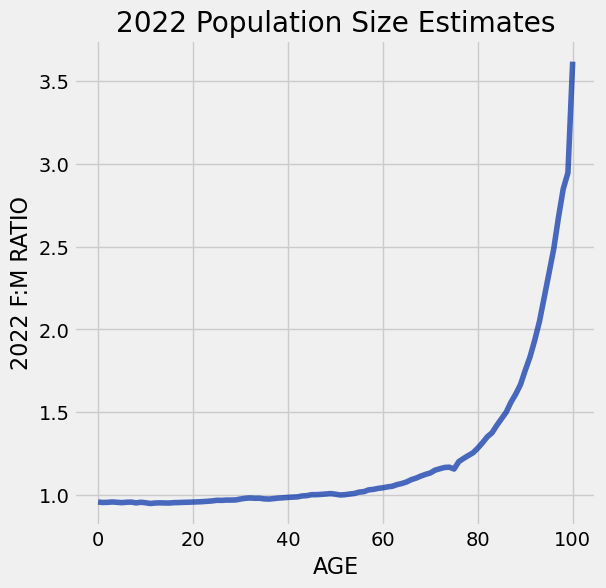

In [74]:
ratios.plot('AGE')

plt.title('2022 Population Size Estimates') 
plt.show()

---

The table actors contains data on Hollywood actors, both male and female. 

In [75]:
actors = Table.read_table('actors.csv')
actors

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9
Scarlett Johansson,3341.2,37,90.3,The Avengers,623.4


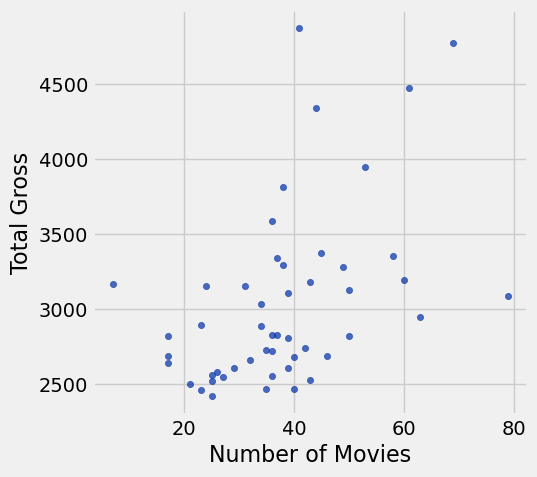

In [76]:
actors.scatter('Number of Movies', 'Total Gross')

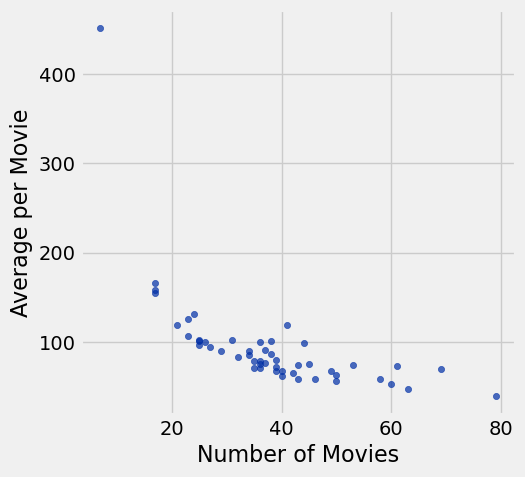

In [77]:
actors.scatter('Number of Movies', 'Average per Movie')

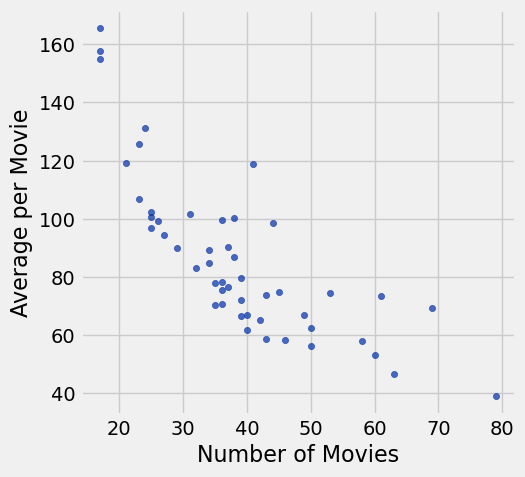

In [78]:
no_outlier = actors.where('Number of Movies', are.above(10))
no_outlier.scatter('Number of Movies', 'Average per Movie')

In [79]:
actors.where('Number of Movies', are.above(60))

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Robert DeNiro,3081.3,79,39,Meet the Fockers,279.3
Liam Neeson,2942.7,63,46.7,The Phantom Menace,474.5


In [80]:
actors.where('Number of Movies', are.below(10))

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Anthony Daniels,3162.9,7,451.8,Star Wars: The Force Awakens,936.7


# Charts

---

## Overview

* [W. E. B. Du Bois](#W.-E.-B.-Du-Bois)
* [Why Do We Visualize Data](#Why-Do-We-Visualize-Data)
* [Course Visualizations](#Course-Visualizations)
* [Categorical Data](#Categorical-Data)
* [Numerical Data](#Numerical-Data)

---

## W. E. B. Du Bois

---

### Background

<a href="https://en.wikipedia.org/wiki/W._E._B._Du_Bois"><img src="./WEB_DuBois_1918.jpeg" alt="W.E.B. Du Bois" width = 20%></a>

* Scholar, historian, activist, and data scientist
    > "The Philadelphia Negro was the first scientific study of race in the world. [...] the first non-racist investigation of a non-white poulation in the world. [...] one of the first social scientific written in the U.S. using the advanced statistical methods of the time." - Dr. Tukufu Zuberi, Professor of Race Relations at the University of Pennsylvania (Source: [A Legacy of Courage: W.E.B. Du Bois and the Philadelphia Negro](https://youtu.be/PQX_0uyDgGw))
* First Black American to receive a PhD from Harvard
* NAACP founder

---

### Paris Exposition

Made a series of visualizations for the 1900 Paris Exposition
* Goal: Change the way people see Black Americans
* Hundreds of photographs and patents
* 60+ handmade graphs in 3 months
> "All art is propaganda, and ever must be, despite the wailing of the purists. I stand in utter shamelessness and say that whatever art I have for writing has been used always for propaganda for gaining the right of black folk to love and enjoy. I do not care a damn for any art that is not used for propaganda." - W.E.B. Du Bois
* Ideologies of W.E.B. Du Bois and Booker T. Washington are typically compared
* The following podcast provides an 11-minute overview of Du Bois and Washington:

In [81]:
from IPython.display import IFrame
IFrame('https://www.youtube-nocookie.com/embed/zHn-vSTMOWE?si=Qk49xkLYJyAlBY5k',
       width="560", height="315", frameBorder="0", allowfullscreen="", 
       allow="accelerometer; autoplay; clipboard-write; \
       encrypted-media; fullscreen; gyroscope; picture-in-picture; web-share", 
       loading="lazy", title="YouTube video player",
       referrerpolicy="strict-origin-when-cross-origin")

---

## Why Do We Visualize Data

* A large fraction of our brains are dedicated to visual reasoning. 
* In Data Science we use visualization:
    * For others – to communicate our findings
    * For ourselves – to understand our data, see patterns, and discover relationships 

---

### Demo: Identifying Data Type of Column Values

The dataset `top_grossing_movies.csv` shows the [highest 100-grossing movies worldwide listed on IMDB](https://www.imdb.com/list/ls564012879/). Adjusted total gross values were also provided using the Consumer Price Index (CPI)-based Python library `cpi` to account for inflation.

In [82]:
top_movies = Table.read_table('top_grossing_movies.csv')
top_movies

Created,Modified,Title,Original Title,URL,Title Type,IMDb Rating,Runtime (mins),Year,Genres,Num Votes,Release Date,Directors,Gross,Gross (Adjusted)
2023-02-03,2023-02-09,Avatar,Avatar,https://www.imdb.com/title/tt0499549/,Movie,7.9,162,2009,"Action, Adventure, Fantasy, Sci-Fi",1444802,2009-12-18,James Cameron,2923706026,4.27495e+09
2023-02-03,2023-08-09,Avengers: Endgame,Avengers: Endgame,https://www.imdb.com/title/tt4154796/,Movie,8.4,181,2019,"Action, Adventure, Sci-Fi",1386907,2019-04-26,"Anthony Russo, Joe Russo",2799439100,3.43489e+09
2023-02-03,2023-05-23,Avatar: The Way of Water,Avatar: The Way of Water,https://www.imdb.com/title/tt1630029/,Movie,7.5,192,2022,"Action, Adventure, Fantasy, Sci-Fi",545046,2022-12-16,James Cameron,2320246732,2.48701e+09
2023-02-03,2023-03-13,Titanic,Titanic,https://www.imdb.com/title/tt0120338/,Movie,7.9,194,1997,"Drama, Romance",1355571,1997-12-19,James Cameron,2255734210,4.40872e+09
2025-03-17,2025-08-19,Ne Zha 2,Nezha: Mo tong nao hai,https://www.imdb.com/title/tt34956443/,Movie,8,144,2025,"Animation, Action, Adventure, Drama, Fantasy",16849,2025-01-29,Yu Yang,2212501921,2.2125e+09
2023-02-03,2023-02-03,Star Wars: Episode VII - The Force Awakens,Star Wars: Episode VII - The Force Awakens,https://www.imdb.com/title/tt2488496/,Movie,7.7,138,2015,"Action, Adventure, Sci-Fi",1009215,2015-12-18,J.J. Abrams,2071310218,2.74135e+09
2023-02-03,2023-02-03,Avengers: Infinity War,Avengers: Infinity War,https://www.imdb.com/title/tt4154756/,Movie,8.4,149,2018,"Action, Adventure, Sci-Fi",1316859,2018-04-27,"Anthony Russo, Joe Russo",2052415039,2.56393e+09
2023-02-03,2024-12-16,Spider-Man: No Way Home,Spider-Man: No Way Home,https://www.imdb.com/title/tt10872600/,Movie,8.2,148,2021,"Action, Adventure, Fantasy, Sci-Fi",975881,2021-12-17,Jon Watts,1952723719,2.26057e+09
2024-12-16,2024-12-16,Inside Out 2,Inside Out 2,https://www.imdb.com/title/tt22022452/,Movie,7.5,96,2024,"Animation, Adventure, Comedy, Drama, Family, Fantasy, Sport",230677,2024-06-14,Kelsey Mann,1698586747,1.69859e+09
2023-02-03,2023-06-07,Jurassic World,Jurassic World,https://www.imdb.com/title/tt0369610/,Movie,6.9,124,2015,"Action, Adventure, Sci-Fi",714491,2015-06-12,Colin Trevorrow,1671537444,2.21226e+09


The movie titles reflect a categorical attribute.

In [83]:
type(top_movies.column('Title').item(0))

str

The movie years reflect a numerical attribute.

In [84]:
type(top_movies.column('Year').item(0))

int

## Categorical Data

---

(Horizontal) Bar charts `barh` are a standard way to visualize the distribution of a single categorical variable.


---

#### A Bar Chart

*The following code uses `group`. We will address that later in the course. Additionally, there is customization to the visual done on the lines that start with `plots`. You are not responsible for this customization.*

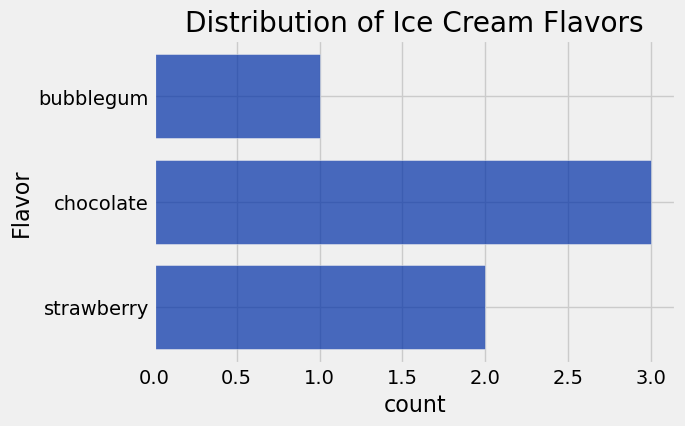

In [85]:
cones = Table().read_table('cones.csv')
cones_grouped_by_flavor = cones.group('Flavor')
cones_grouped_by_flavor.barh('Flavor')

plt.title('Distribution of Ice Cream Flavors')
plt.show()

---

### Demo: Bar Charts

Reduce the table to the top 10 movies based on actual gross values (`'Gross (Adjusted)'`) for the movies released in the last decade.

In [86]:
top_movies_select = top_movies.select('Title', 'Year', 'Gross (Adjusted)')

top_movies_last_decade = top_movies_select.take(np.arange(10)) 
top_movies_last_decade_sorted = top_movies_last_decade.sort('Title')
top10 = top_movies_last_decade_sorted.take(np.arange(0, 9))
top10

Title,Year,Gross (Adjusted)
Avatar,2009,4.27495e+09
Avatar: The Way of Water,2022,2.48701e+09
Avengers: Endgame,2019,3.43489e+09
Avengers: Infinity War,2018,2.56393e+09
Inside Out 2,2024,1.69859e+09
Jurassic World,2015,2.21226e+09
Ne Zha 2,2025,2.2125e+09
Spider-Man: No Way Home,2021,2.26057e+09
Star Wars: Episode VII - The Force Awakens,2015,2.74135e+09


---

Returning to top grossing movies data, convert to the gross (adjusted) values in the `top10` table to millions of dollars for readability.

In [87]:
# Convert to millions of dollars for readability
millions = np.round(top10.column('Gross (Adjusted)') / 1000000, 3)
top10_adjusted = top10.with_column('Millions', millions)
top10_adjusted

Title,Year,Gross (Adjusted),Millions
Avatar,2009,4.27495e+09,4274.95
Avatar: The Way of Water,2022,2.48701e+09,2487.01
Avengers: Endgame,2019,3.43489e+09,3434.89
Avengers: Infinity War,2018,2.56393e+09,2563.93
Inside Out 2,2024,1.69859e+09,1698.59
Jurassic World,2015,2.21226e+09,2212.26
Ne Zha 2,2025,2.2125e+09,2212.5
Spider-Man: No Way Home,2021,2.26057e+09,2260.57
Star Wars: Episode VII - The Force Awakens,2015,2.74135e+09,2741.35


---

Visualize the gross adjusted values for each of the top 10 grossing (adjusted) movies.

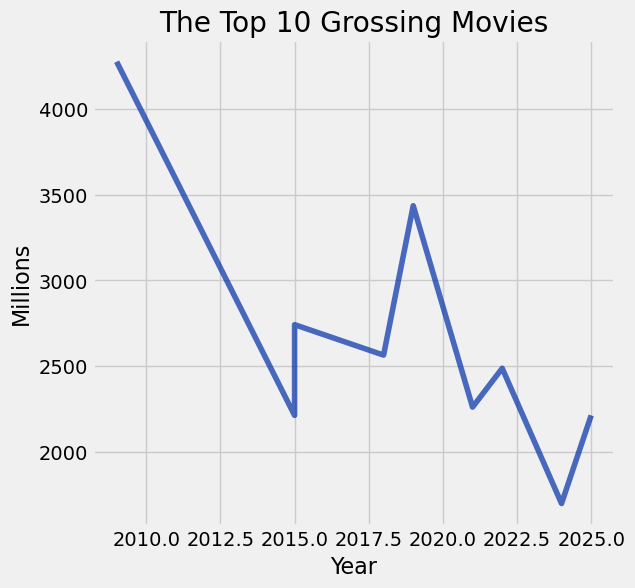

In [88]:

top10_adjusted.plot('Year', 'Millions')

plt.title("The Top 10 Grossing Movies")
plt.show()

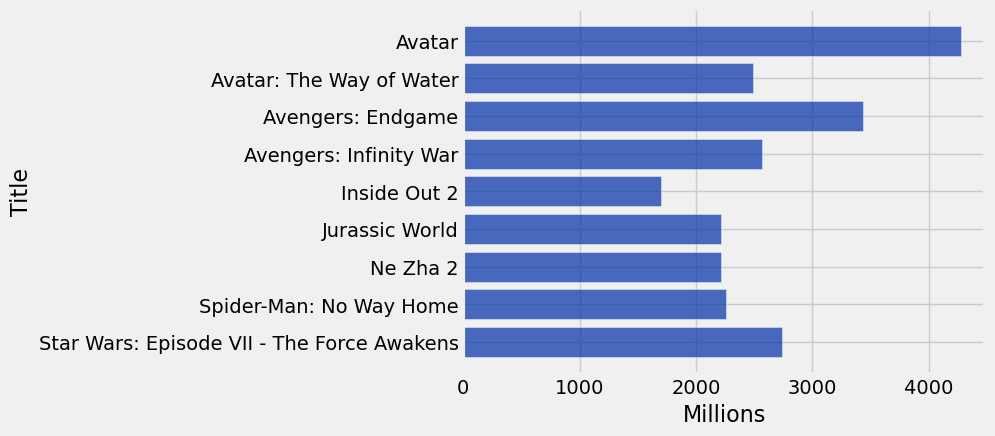

In [89]:
top10_adjusted.barh('Title', 'Millions')

### Demo: Visualizing Du Bois

<img src="./WEB_DuBois_income_and_expenditure.jpeg" alt="Du Bois's graphic of Income and Expenditures" width = 50%>

Read the `du_bois.csv` data as a table, reformat the data, and create a stacked bar chart.

In [90]:
du_bois = Table.read_table('du_bois.csv')
du_bois.set_format('RENT', PercentFormatter)
du_bois.set_format('FOOD', PercentFormatter)
du_bois.set_format('CLOTHES', PercentFormatter)
du_bois.set_format('TAXES', PercentFormatter)
du_bois.set_format('OTHER', PercentFormatter)
du_bois

CLASS,ACTUAL AVERAGE,RENT,FOOD,CLOTHES,TAXES,OTHER,STATUS
100-200,139.1,19.00%,43.00%,28.00%,0.10%,9.90%,POOR
200-300,249.45,22.00%,47.00%,23.00%,4.00%,4.00%,POOR
300-400,335.66,23.00%,43.00%,18.00%,4.50%,11.50%,FAIR
400-500,433.82,18.00%,37.00%,15.00%,5.50%,24.50%,FAIR
500-750,547,13.00%,31.00%,17.00%,5.00%,34.00%,COMFORTABLE
750-1000,880,0.00%,37.00%,19.00%,8.00%,36.00%,COMFORTABLE
1000 and over,1125,0.00%,29.00%,16.00%,4.50%,50.50%,WELL-TO-DO


---

Notice that the table is formatted to show percentages, but the values in the % columns are actually floats. 

In [96]:
du_bois.column('RENT')

array([ 0.19,  0.22,  0.23,  0.18,  0.13,  0.  ,  0.  ])

In [97]:
type(du_bois.column('RENT').item(0))

float

In [ ]:
food_dollars = du_bois.column('ACTUAL AVERAGE') * du_bois.column('FOOD')
du_bois.with_column('Food $', food_dollars)

In [ ]:
food_dollars = du_bois.column('ACTUAL AVERAGE') * du_bois.column('FOOD')
du_bois = du_bois.with_column('Food $', food_dollars)
du_bois

In [ ]:
np.max(du_bois.column('Food $'))

In [ ]:
du_bois.with_column(
    'Fraction of well-to-do food $', 
    du_bois.column('Food $') / np.max(du_bois.column('Food $')))

---

Start to re-create the bar chart that Du Bois presented in Paris.

In [99]:
du_bois_for_bar = du_bois.drop('ACTUAL AVERAGE', 'STATUS')
du_bois_for_bar

CLASS,RENT,FOOD,CLOTHES,TAXES,OTHER
100-200,19.00%,43.00%,28.00%,0.10%,9.90%
200-300,22.00%,47.00%,23.00%,4.00%,4.00%
300-400,23.00%,43.00%,18.00%,4.50%,11.50%
400-500,18.00%,37.00%,15.00%,5.50%,24.50%
500-750,13.00%,31.00%,17.00%,5.00%,34.00%
750-1000,0.00%,37.00%,19.00%,8.00%,36.00%
1000 and over,0.00%,29.00%,16.00%,4.50%,50.50%


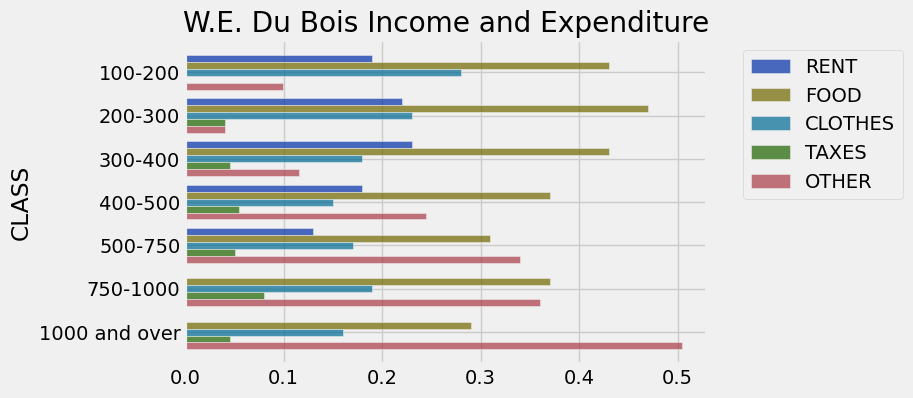

In [100]:
du_bois_for_bar.barh('CLASS')
plt.title('W.E. Du Bois Income and Expenditure')
plt.show()

---

## Numerical Data

---

### Visualizing the Distribution of One Numerical Variable

Histograms `tbl.hist` are a standard way to visualize the distribution of one numerical variable.

*Histograms will be focused on in the next lecture.*

---

#### A Histogram

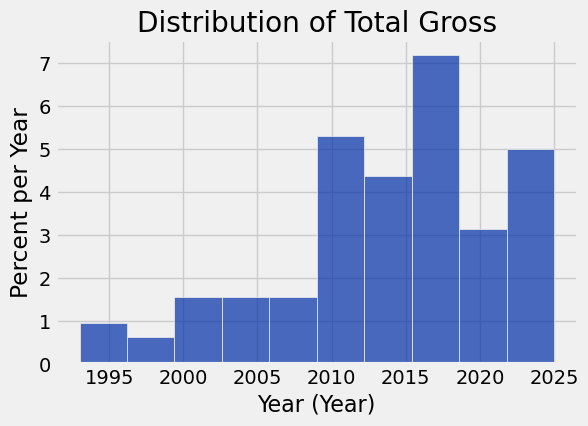

In [103]:
top_movies.hist('Year', unit="Year") 

plt.title('Distribution of Total Gross')
plt.show()

---

### Plotting Two Numerical Variables

Line graphs `tbl.plot` and Scatter plots `tbl.scatter` are standard ways to visualize the relationship of two numerical variables.

---

#### A Line Graph

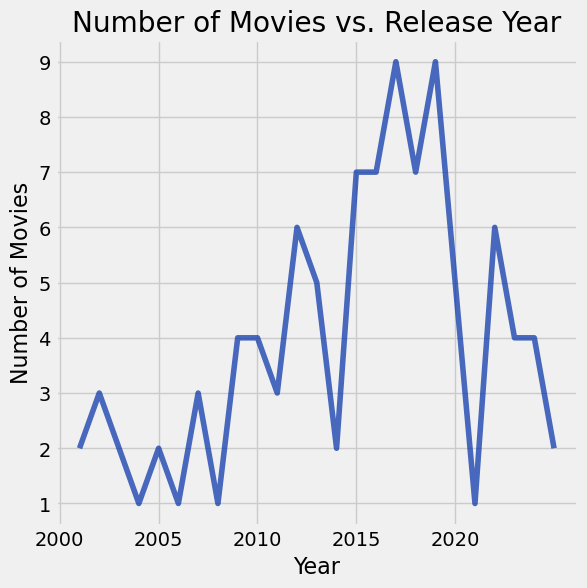

In [104]:
movies_per_year = top_movies.group('Year').relabeled('count', 'Number of Movies')
movies_per_year.where('Year', are.above(1999)).plot('Year', 'Number of Movies') 

plt.xticks(np.arange(2000, 2025, 5))
plt.title('Number of Movies vs. Release Year')
plt.show()

---

#### A Scatter Plot

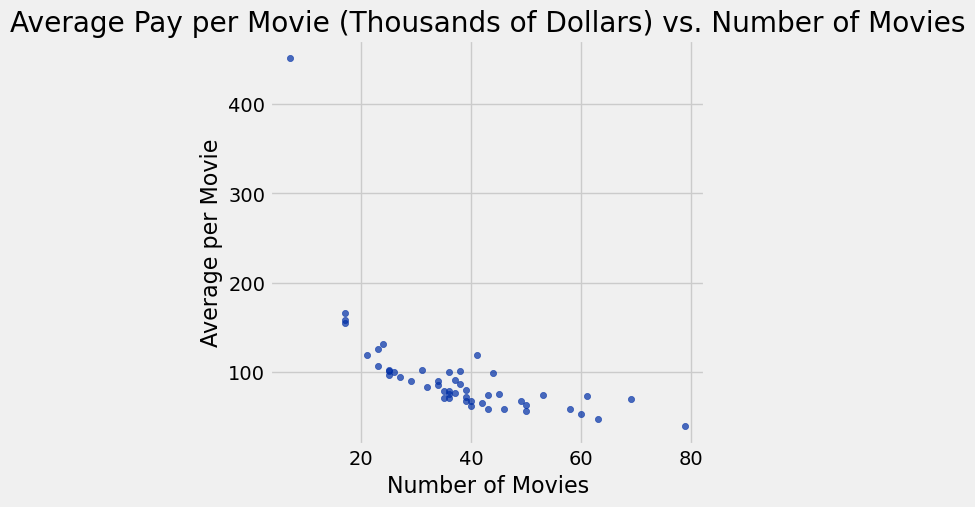

In [105]:
actors = Table.read_table('actors.csv')
actors.scatter('Number of Movies', 'Average per Movie')

plt.title('Average Pay per Movie (Thousands of Dollars) vs. Number of Movies')
plt.show()

---

### When to use a line vs scatter plot?

* Use line plots for sequential data if:
    * ... your x-axis has an order
    * ... sequential differences in y values are meaningful
    * ... there's only one y-value for each x-value
* Usually: x-axis is time or distance
* Use scatter plots for non-sequential data --- When you’re looking for associations


---

### Demo: Scatter Plots

Visualize the relationship between the IMDb rating and the number of votes for the movies in `top_movies`.

In [106]:
top_movies.show(3)

Created,Modified,Title,Original Title,URL,Title Type,IMDb Rating,Runtime (mins),Year,Genres,Num Votes,Release Date,Directors,Gross,Gross (Adjusted)
2023-02-03,2023-02-09,Avatar,Avatar,https://www.imdb.com/title/tt0499549/,Movie,7.9,162,2009,"Action, Adventure, Fantasy, Sci-Fi",1444802,2009-12-18,James Cameron,2923706026,4.27495e+09
2023-02-03,2023-08-09,Avengers: Endgame,Avengers: Endgame,https://www.imdb.com/title/tt4154796/,Movie,8.4,181,2019,"Action, Adventure, Sci-Fi",1386907,2019-04-26,"Anthony Russo, Joe Russo",2799439100,3.43489e+09
2023-02-03,2023-05-23,Avatar: The Way of Water,Avatar: The Way of Water,https://www.imdb.com/title/tt1630029/,Movie,7.5,192,2022,"Action, Adventure, Fantasy, Sci-Fi",545046,2022-12-16,James Cameron,2320246732,2.48701e+09


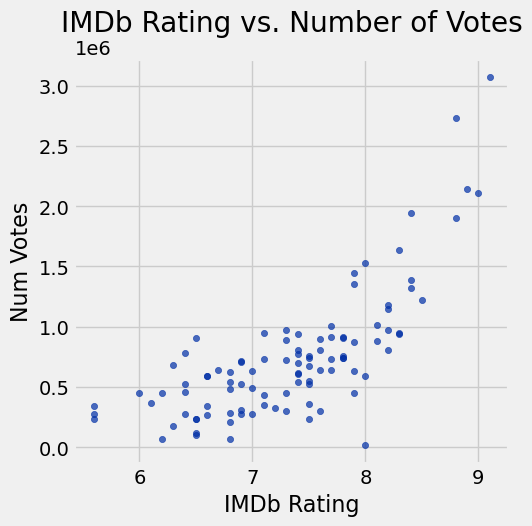

In [108]:
top_movies.scatter('IMDb Rating', 'Num Votes')
# Some extra graph formatting you are not responsible for
plt.title('IMDb Rating vs. Number of Votes')
plt.show()

---

## Attribution

This content is licensed under the <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0)</a> and derived from the <a href="https://www.data8.org/">Data 8: The Foundations of Data Science</a> offered by the University of California, Berkeley.

<img src="./by-nc-sa.png" width=100px>